In [24]:
import json
import pandas as pd
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx

In [38]:
# =========================================
# STEP 1. 파일 전체 로딩 + 기사 단위 처리
# =========================================

# JSON 파일 목록
file_paths = {
    "이재명": "이재명.json",
    "김문수": "김문수.json",
    "이준석": "이준석.json"
}

# 불용어 리스트 정의
stopwords = {
    '대하', '주', '두', '되', '위하', '하', '없', '같', '말', '있',
    '않', '아니', '전', '그', '보', '이날', '선거', '한', '가', '기자', '안'
}

# 전체 기사 리스트 저장용
all_articles = []  # 각 원소: {'source': '김문수', 'tokens': [...]}

# 각 JSON 파일에서 기사 불러오기
for name, path in file_paths.items():
    with open(path, encoding='utf-8') as f:
        data = json.load(f)

    for article in data:
        text = article.get('content', '')
        
        # 형태소 분리된 '단어(품사)'에서 '단어'만 추출
        tokens = [token.rsplit("(", 1)[0] for token in text.split() if '(' in token]
        tokens = [t for t in tokens if t not in stopwords]  # 불용어 제거

        if tokens:
            all_articles.append({
                'source': name,
                'tokens': tokens
            })

In [39]:
# =========================================
# STEP 2. 공출현 네트워크 생성 함수 (기사 단위 기준)
# =========================================

def generate_cooccurrence_from_articles(articles, target_words):
    """
    주어진 단어들이 모두 포함된 기사에서만 공출현 쌍 계산
    """
    cooccurrence = defaultdict(lambda: defaultdict(int))

    for article in articles:
        tokens = article['tokens']

        if all(t in tokens for t in target_words):
            unique_tokens = list(set(tokens))
            for i in range(len(unique_tokens)):
                for j in range(i + 1, len(unique_tokens)):
                    w1, w2 = unique_tokens[i], unique_tokens[j]
                    cooccurrence[w1][w2] += 1
                    cooccurrence[w2][w1] += 1

    return cooccurrence

In [40]:
# =========================================
# STEP 3. 공출현 시각화 함수
# =========================================

def visualize_from_cooccurrence(cooccurrence, target_words, top_k=30, font_name='Malgun Gothic'):
    """
    공출현 딕셔너리를 시각화합니다.
    - 타겟 단어는 반드시 그래프에 표시됩니다
    """
    edge_counter = []

    for w1 in cooccurrence:
        for w2, count in cooccurrence[w1].items():
            if w1 in target_words or w2 in target_words:
                if w1 != w2:
                    edge_counter.append((w1, w2, count))

    edge_counter = sorted(edge_counter, key=lambda x: x[2], reverse=True)[:top_k]

    G = nx.Graph()
    for w1, w2, weight in edge_counter:
        G.add_edge(w1, w2, weight=weight)

    for word in target_words:
        if word not in G.nodes:
            G.add_node(word)

    plt.rc('font', family=font_name)
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges()] if G.edges else []

    nx.draw(
        G, pos,
        with_labels=True, node_size=1500,
        edge_color=weights, edge_cmap=plt.cm.Blues,
        width=2, node_color='lightblue',
        font_family=font_name
    )

    plt.title(f"공출현 네트워크 (기사 단위): {', '.join(target_words)}", fontsize=14)
    plt.show()

In [ ]:
# =========================================
# STEP 4. 실행 예시
# =========================================

'''
target_words = ['김문수', '단일']  # 찾고 싶은 단어쌍

cooccurrence = generate_cooccurrence_from_articles(all_articles, target_words)

visualize_from_cooccurrence(cooccurrence, target_words, top_k=30)
'''

"\n# 원하는 단어쌍 입력\ntarget_words = ['김문수', '이준석']\n\n# 해당 단어쌍이 동시에 등장한 문장에서만 공출현 분석\ncooccurrence = generate_cooccurrence_network(all_sentences, target_words)\n\n# 시각화 실행\nvisualize_from_cooccurrence(cooccurrence, target_words, top_k=30)\n"

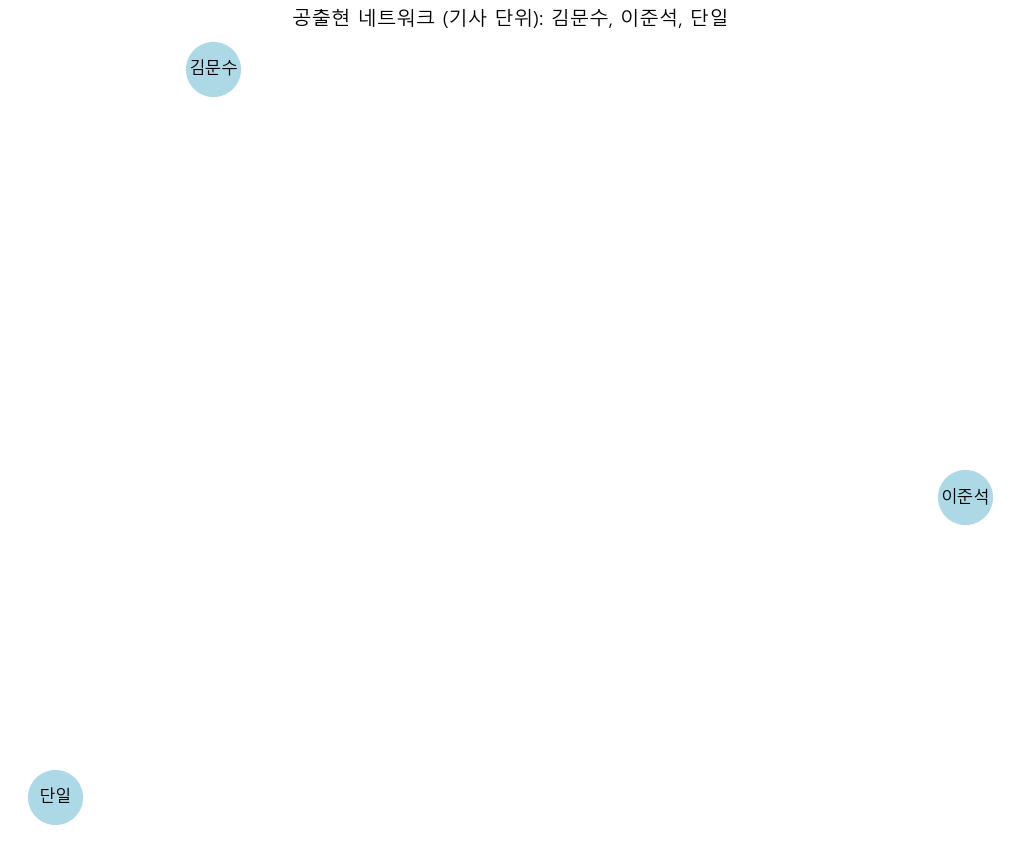

In [43]:
target_words = ['김문수', '이준석', '단일']  # 찾고 싶은 단어쌍

cooccurrence = generate_cooccurrence_from_articles(all_articles, target_words)

visualize_from_cooccurrence(cooccurrence, target_words, top_k=30)